###### Polytech Paris-Saclay | 3e année

# TP3 Algo-Num-1 : méthodes itératives

Contexte : dans ce TP, on s'intéresse à la résolution approchée de systèmes linéaires `Ax=b` par des méthodes itératives. Contrairement aux méthodes directes, on part d'une approximation initiale `x^(0)` et on construit une suite de vecteurs qui converge vers la solution.

Objectifs :
- manipuler la décomposition `A = D - E - F` ;
- coder les méthodes de Jacobi et de Gauss-Seidel ;
- utiliser un critère d'arrêt ;
- comparer numériquement les vitesses de convergence.


In [22]:
import numpy as np
import numpy.random as rd
import matplotlib.pyplot as plt

## 1. Préliminaires
### 1.1 Construire une matrice `A` et un vecteur `b`
On pourra commencer avec l'exemple suivant :

```python
A = np.array([[4., -1.,  0.],
              [-1., 4., -1.],
              [0., -1.,  4.]])
b = np.array([3., 4., 3.])
```


In [23]:
A = np.array([[4., -1.,  0.],
            [-1., 4., -1.],
            [0., -1.,  4.]])
b = np.array([3., 4., 3.])

C = np.array([[4., 3.,  0.],
            [-1., 4., -1.],
            [0., -1.,  4.]])

### 1.2 Vérifier que `A` est à diagonale dominante
Pour chaque ligne `i`, comparer `|a_ii|` à la somme des valeurs absolues des autres coefficients de la ligne.


In [24]:
def diagonale_dominante(A):
    for i in range(A.shape[0]):
        # Je somme tous les termes de la ligne et je soustrait la diagonale
        somme = np.sum(abs(A[i])) - abs(A[i][i])
        if abs(A[i][i]) <= somme:
            return False
    return True

### 1.3 Extraire les matrices `D`, `E`, `F`
En utilisant les notations du cours :
- `D` est la diagonale de `A`
- `E` est l'opposé de la partie triangulaire inférieure stricte de `A`
- `F` est l'opposé de la partie triangulaire supérieure stricte de `A`

Vérifier numériquement que :

```python
A = D - E - F
```


In [25]:
def makeD(A):
    return np.diag(np.diag(A))

def makeE(A):
    return np.tril(A, k=-1) * -1

def makeF(A):
    return np.triu(A, k=1) * -1

D = makeD(A)
E = makeE(A)
F = makeF(A)

print(np.allclose(A, D - E - F))

True


## 2. Méthode de Jacobi
### 2.1 Coder la fonction `Jacobi(A, b, x0, tol, nmax)`
La fonction prendra en entrée :
- `A` la matrice
- `b` le second membre
- `x0` une approximation initiale
- `tol` une tolérance
- `nmax` un nombre maximal d'itérations

La fonction renverra :
- la solution approchée
- le nombre d'itérations effectuées
- l'historique des résidus `||b - A x^(k)||_2`

On pourra suivre le schéma mathématique suivant :

$$
\text{Initialisation : } x^{(0)} = x_0
$$

$$
\text{Pour } k = 0, 1, 2, \dots, n_{max}-1
$$

$$
\text{Pour } i = 0, 1, \dots, n-1,
\qquad
x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j \ne i} a_{ij} x_j^{(k)}\right)
$$

$$
r^{(k+1)} = b - A x^{(k+1)}
$$

On s'arrête lorsque `||r^(k+1)||_2 <= tol`.

Autrement dit, pour Jacobi, toutes les composantes de `x^(k+1)` sont calculées à partir de `x^(k)`.


In [26]:
def Jacobi(A, b, x0, tol, nmax):
    n = len(b)
    x_old = x0.copy().astype(float)
    x_new = np.zeros_like(x_old)
    residuels = [np.linalg.norm(b - A @ x_old)]

    for k in range(nmax):
        for i in range(n):
            somme = 0
            for j in range(n):
                # j différent de i
                if j != i:
                    somme += A[i][j] * x_old[j]
            x_new[i] = (b[i] - somme) / A[i][i]

        r = np.linalg.norm(b - A @ x_new)
        residuels.append(r)

        if r <= tol:
            return x_new, k + 1, residuels

        x_old = x_new.copy()

    return x_new, nmax, residuels

### 2.2 Tester `Jacobi`
Prendre par exemple :

```python
x0 = np.zeros(3)
tol = 1e-8
nmax = 100
```

Afficher :
- la solution approchée
- le nombre d'itérations
- le résidu final


In [27]:
x0 = np.zeros(3)
tol = 1e-8
nmax = 100

xJ, nmaxJ, residuelsJ = Jacobi(A, b, x0, tol, nmax)
print("Solution approchée:", xJ)
print("Nombre d'itérations:", nmaxJ)

Solution approchée: [1.14285714 1.57142857 1.14285714]
Nombre d'itérations: 20


### 2.3 Tracer l'évolution du résidu
Tracer en fonction du numéro d'itération la quantité

```python
||b - A x^(k)||
```


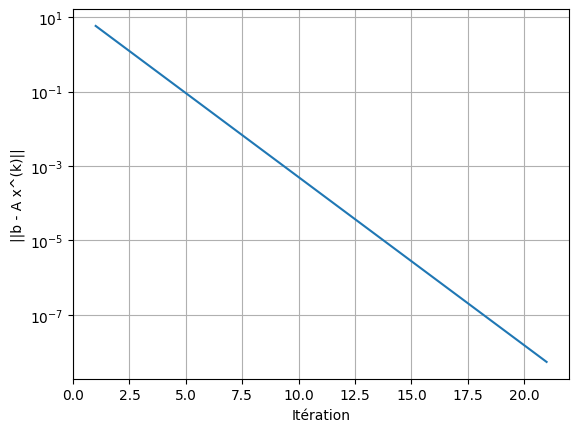

In [28]:
plt.semilogy(range(1, len(residuelsJ) + 1), residuelsJ)

plt.xlabel("Itération")
plt.ylabel("||b - A x^(k)||")

plt.grid()

plt.show()

## 3. Méthode de Gauss-Seidel
### 3.1 Coder la fonction `GaussSeidel(A, b, x0, tol, nmax)`
Même principe que pour Jacobi, mais en réutilisant immédiatement les nouvelles valeurs calculées dans l'itération courante.

La fonction renverra :
- la solution approchée
- le nombre d'itérations effectuées
- l'historique des résidus

On pourra suivre le schéma mathématique suivant :

$$
\text{Initialisation : } x^{(0)} = x_0
$$

$$
\text{Pour } k = 0, 1, 2, \dots, n_{max}-1
$$

$$
\text{Pour } i = 0, 1, \dots, n-1,
\qquad
x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j < i} a_{ij} x_j^{(k+1)} - \sum_{j > i} a_{ij} x_j^{(k)}\right)
$$

$$
r^{(k+1)} = b - A x^{(k+1)}
$$

On s'arrête lorsque `||r^(k+1)||_2 <= tol`.

La différence avec Jacobi est que Gauss-Seidel réutilise immédiatement les nouvelles valeurs déjà calculées dans l'itération courante.


In [29]:
def GaussSeidel(A, b, x0, tol, nmax):
    n = len(b)
    x = x0.copy().astype(float)
    residuels = [np.linalg.norm(b - A @ x0)]

    for k in range(nmax):
        for i in range(n):
            somme1, somme2 = 0, 0

            for j in range(i):
                somme1 += A[i][j] * x[j]

            for j in range(i + 1, n):
                somme2 += A[i][j] * x0[j]

            x[i] = (b[i] - somme1 - somme2) / A[i][i]

        r = np.linalg.norm(b - A @ x)
        residuels.append(r)

        if r <= tol:
            return x, k + 1, residuels

        x0 = x.copy()

    return x, nmax, residuels

### 3.2 Tester `GaussSeidel`
Utiliser les mêmes données que pour Jacobi et afficher :
- la solution approchée
- le nombre d'itérations
- le résidu final


In [30]:
xGS, nmaxGS, residuelsGS = GaussSeidel(A, b, x0, tol, nmax)
print("Solution approchée:", xGS)
print("Nombre d'itérations:", nmaxGS)

Solution approchée: [1.14285714 1.57142857 1.14285714]
Nombre d'itérations: 11


### 3.3 Tracer l'évolution du résidu
Tracer l'historique des résidus pour Gauss-Seidel.


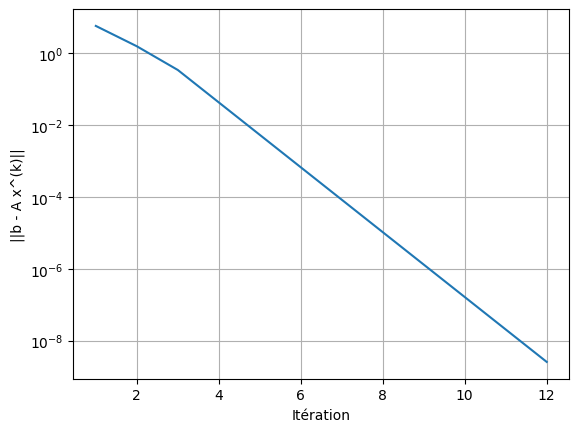

In [31]:
plt.semilogy(range(1, len(residuelsGS) + 1), residuelsGS)

plt.xlabel("Itération")
plt.ylabel("||b - A x^(k)||")

plt.grid()

plt.show()

## 4. Comparaison des deux méthodes
### 4.1 Comparer Jacobi et Gauss-Seidel
Pour la même matrice `A`, le même vecteur `b`, la même initialisation `x0` et la même tolérance :
- comparer les nombres d'itérations
- comparer les résidus finaux
- commenter la vitesse de convergence


In [32]:
print("Itération Jacobi:", nmaxJ)
print("Itération Gauss-Seidel:", nmaxGS)
print()
print("Résidus final Jacobi:", residuelsJ[-1])
print("Résidus final Gauss-Seidel:", residuelsGS[-1])

Itération Jacobi: 20
Itération Gauss-Seidel: 11

Résidus final Jacobi: 5.4304971311663284e-09
Résidus final Gauss-Seidel: 2.5799605922883987e-09


La vitesse de convergence va plus rapidement avec la méthode Gauss-Seidel.

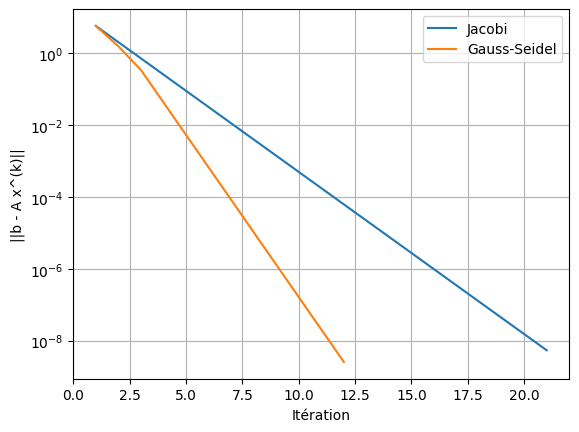

In [33]:
def comparaison(residuelsJ, residuelsGS):
    plt.semilogy(
        range(1, len(residuelsJ) + 1),
        residuelsJ,
        label="Jacobi"
    )
    plt.semilogy(
        range(1, len(residuelsGS) + 1), 
        residuelsGS,
        label="Gauss-Seidel"
    )

    plt.xlabel("Itération")
    plt.ylabel("||b - A x^(k)||")

    plt.grid()
    plt.legend()

    plt.show()

comparaison(residuelsJ, residuelsGS)

### 4.2 Changer l'approximation initiale
Tester plusieurs choix de `x0` :
- vecteur nul
- vecteur de 1
- vecteur aléatoire

Commenter l'influence de `x0`.


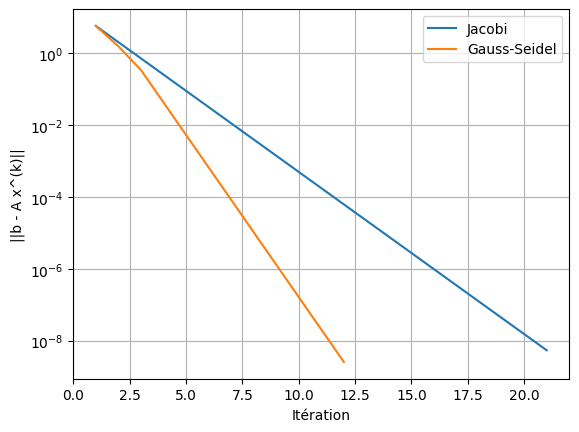

In [34]:
x0 = np.zeros(3)

xJ, nmaxJ, residuelsJ = Jacobi(A, b, x0, tol, nmax)
xGS, nmaxGS, residuelsGS = GaussSeidel(A, b, x0, tol, nmax)

comparaison(residuelsJ, residuelsGS)

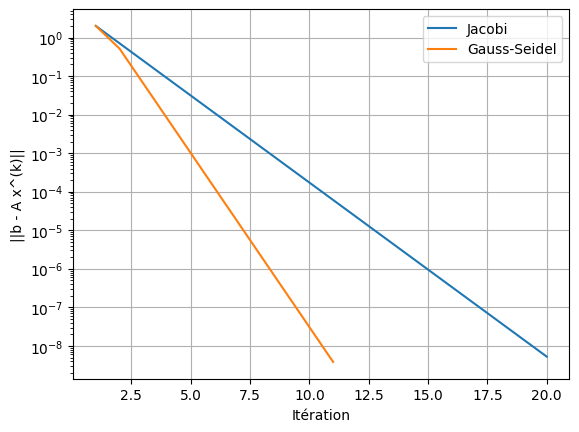

In [35]:
x0 = np.ones(3)

xJ, nmaxJ, residuelsJ = Jacobi(A, b, x0, tol, nmax)
xGS, nmaxGS, residuelsGS = GaussSeidel(A, b, x0, tol, nmax)

comparaison(residuelsJ, residuelsGS)

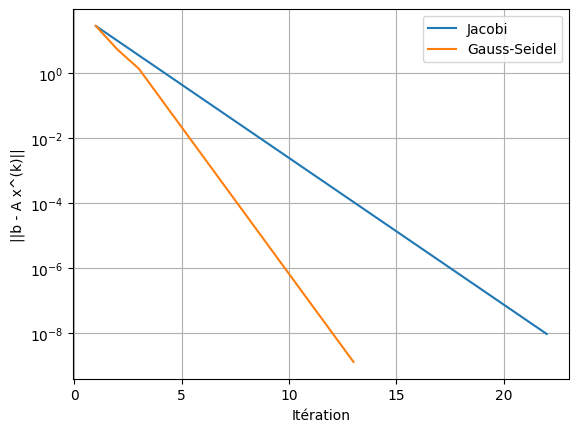

In [36]:
np.random.seed(42) # Reproductibilité
x0 = np.random.randint(10, size=3)

xJ, nmaxJ, residuelsJ = Jacobi(A, b, x0, tol, nmax)
xGS, nmaxGS, residuelsGS = GaussSeidel(A, b, x0, tol, nmax)

comparaison(residuelsJ, residuelsGS)

### 4.3 Tester un second exemple
On considère maintenant la matrice diagonale dominante suivante :

```python
A2 = np.array([[6., -1.,  0.,  0.,  0.],
               [-1., 6., -1.,  0.,  0.],
               [0., -1., 6., -1.,  0.],
               [0.,  0., -1., 6., -1.],
               [0.,  0.,  0., -1., 6.]])
b2 = np.array([5., 4., 3., 2., 1.])
```

Refaire les tests précédents sur ce second exemple et comparer Jacobi et Gauss-Seidel.


In [37]:
A2 = np.array([[6., -1.,  0.,  0.,  0.],
                [-1., 6., -1.,  0.,  0.],
                [0., -1., 6., -1.,  0.],
                [0.,  0., -1., 6., -1.],
                [0.,  0.,  0., -1., 6.]])
b2 = np.array([5., 4., 3., 2., 1.])

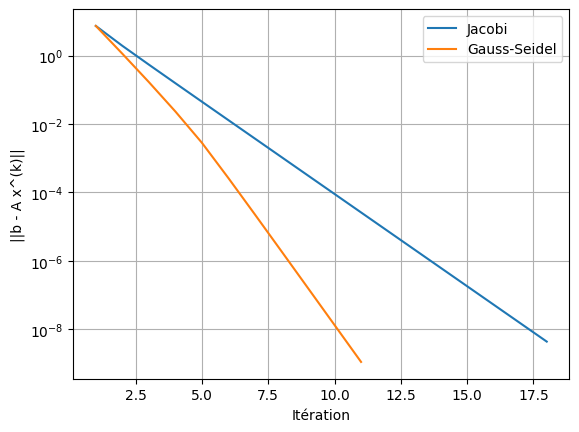

In [38]:
x0 = np.zeros(5)

xJ, nmaxJ, residuelsJ = Jacobi(A2, b2, x0, tol, nmax)
xGS, nmaxGS, residuelsGS = GaussSeidel(A2, b2, x0, tol, nmax)

comparaison(residuelsJ, residuelsGS)

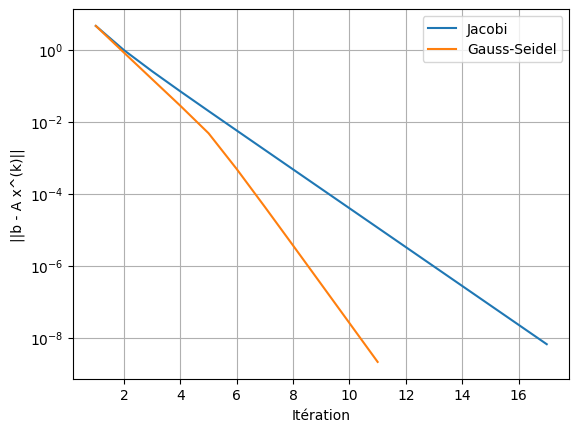

In [39]:
x0 = np.ones(5)

xJ, nmaxJ, residuelsJ = Jacobi(A2, b2, x0, tol, nmax)
xGS, nmaxGS, residuelsGS = GaussSeidel(A2, b2, x0, tol, nmax)

comparaison(residuelsJ, residuelsGS)

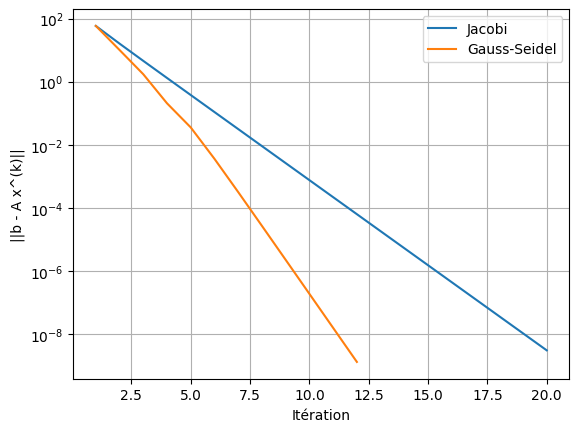

In [40]:
x0 = np.random.randint(10, size=5)

xJ, nmaxJ, residuelsJ = Jacobi(A2, b2, x0, tol, nmax)
xGS, nmaxGS, residuelsGS = GaussSeidel(A2, b2, x0, tol, nmax)

comparaison(residuelsJ, residuelsGS)

## Bonus
### 5.1 Comparaison avec la solution exacte
Comparer les solutions approchées avec la solution obtenue par

```python
np.linalg.solve(A, b)
```


In [41]:
solution_reelle = np.linalg.solve(A2, b2)

print(solution_reelle)
print(xJ)
print(xGS)

print(np.allclose(solution_reelle, xJ, xGS))

[0.99264069 0.95584416 0.74242424 0.4987013  0.24978355]
[0.99264069 0.95584416 0.74242424 0.4987013  0.24978355]
[0.99264069 0.95584416 0.74242424 0.4987013  0.24978355]
True


### 5.2 Ouverture
Question bonus : lire dans la documentation SciPy la fonction de gradient conjugué et préciser dans quel cas elle s'applique.
